<a href="https://colab.research.google.com/github/chaiyawat19/DataScinceLab/blob/main/Lab10_Clustering_SegmentCustomer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Partition Clustering

K-Mean Clutering

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df=pd.read_csv('/content/marketing_campaign.csv', sep='\t', index_col=False)
df.head(10)

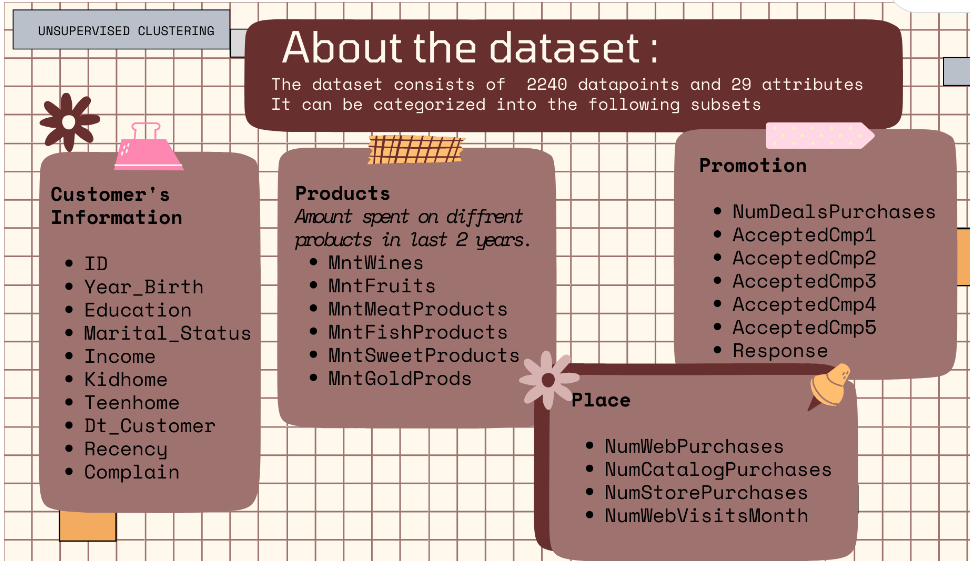
source: kaggle.com

In [ ]:
df.columns

In [ ]:
df.dtypes

In [ ]:
from sklearn.preprocessing import LabelEncoder
# creating instance of labelencoder
labelencoder = LabelEncoder()
df['Education'] = labelencoder.fit_transform(df['Education'])
df['Marital_Status'] = labelencoder.fit_transform(df['Marital_Status'])

In [ ]:
df['Age'] = 2024 - df.Year_Birth

In [ ]:
df.drop(['ID','Dt_Customer', 'Year_Birth'], axis=1, inplace=True)

In [ ]:
df.isnull().sum()

In [ ]:
df.columns

In [ ]:
df.shape

In [ ]:
df.dropna(inplace=True)

Choose k by elbow method

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
# k means determine k
distortions = []
K = range(1,10)
for k in K:
    clustering_model = KMeans(n_clusters=k)
    clustering_model.fit(df)
    distortions.append(clustering_model.inertia_)
# Plot the elbow
plt.plot(K, distortions, 'bx-')
plt.xlabel('k')
plt.ylabel('Distortion')
plt.title('The Elbow Method showing the optimal k')
plt.show()

In [ ]:
from sklearn.cluster import KMeans
clustering_model = KMeans(n_clusters=3)
clustering_model

In [ ]:
output_cluster = clustering_model.fit_predict(df)

evaluation of inter minimized with sse(sum square error) measure  

In [ ]:
sse = clustering_model.inertia_
sse

In [ ]:
df['cluster'] = output_cluster
df

In [ ]:
import plotly.express as px
fig = px.scatter_matrix(df, dimensions=["Education","Marital_Status", "Income"], color="cluster")
fig.show()

In [ ]:
cluster1 = df[df['cluster']== 0]
cluster1.describe()

In [ ]:
cluster1

In [ ]:
cluster2 = df[df['cluster']== 1]
cluster2.describe()

In [ ]:
cluster2

In [ ]:
cluster3 = df[df['cluster']== 2]
cluster3.describe()

In [ ]:
cluster3